In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv; load_dotenv("C:\git-repository\BLS_prediction_project\BLS_jobs_report_model\.env")
import requests
import xgboost as xgb
from pandas_datareader import data as pdr 
from sklearn.model_selection import (TimeSeriesSplit, RandomizedSearchCV, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    ConfusionMatrixDisplay
)

<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:8: SyntaxWarning: invalid escape sequence '\g'
C:\Users\paulp\AppData\Local\Temp\ipykernel_40332\1642311177.py:8: SyntaxWarning: invalid escape sequence '\g'
  from dotenv import load_dotenv; load_dotenv("C:\git-repository\BLS_prediction_project\BLS_jobs_report_model\.env")


## **Modeling Surprises with Multinomial Classification**

In [2]:
master_df = pd.read_csv('master_df.csv')

In [3]:
master_df.head()

,Unnamed: 0,DATE,payrolls,unemployment_rate,initial_claims,cont_claims,2yr_yield,10yr_yield,10yr_2yr_spread,sentiment,...,discharge_momentum,log_initial_claims,hire_rate_squared,unemployment_rate_log,payrolls_pct_change,predicted_payrolls,predicted_payrolls_pct_change,upside_surprise,downside_surprise,surprise
0,0,2001-07-31,132172.0,4.6,398000.0,3030750.0,4.038571,5.236190,1.197619,92.4,...,0.005556,12.894207,12.960000,1.526056,NaN,132401.671812,NaN,0,0,1
1,1,2001-08-31,132021.0,4.9,398000.0,3120000.0,3.757391,4.971304,1.213913,91.5,...,0.005556,12.894207,13.000031,1.589235,-0.001142,132209.058614,-0.001455,0,1,0
2,2,2001-09-30,131763.0,5.0,435000.0,3262200.0,3.118824,4.731765,1.612941,81.8,...,-0.011111,12.983101,13.000031,1.609438,-0.001954,132008.549229,-0.001517,0,1,0
3,3,2001-10-31,131452.0,5.3,480750.0,3527500.0,2.725909,4.566818,1.840909,82.7,...,-0.016667,13.083103,13.080278,1.667707,-0.002360,131610.863406,-0.003013,0,1,0
4,4,2001-11-30,131144.0,5.5,447500.0,3656500.0,2.782500,4.651500,1.869000,83.9,...,-0.016667,13.011432,12.920031,1.704748,-0.002343,131410.783330,-0.001520,0,1,0


In [4]:
features = [
    'sentiment_lag1',
    'payrolls_lag1',
    'unemployment_rate_3mo_avg',
    'initial_claims_lag1',
    'initial_claims_momentum',
    'cont_claims_lag1',
    'cont_claims_momentum',
    '2yr_yield_volatility',
    '10yr_yield_volatility',
    'jor_3mo_avg',
    'jor_momentum',
    'hire_3mo_avg',
    'hire_momentum',
    'quit_3mo_avg',
    'quit_momentum',
    'discharge_3mo_avg',
    'discharge_momentum'
]

X = master_df[features]
y = master_df['surprise']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [5]:
xgb_multi = xgb.XGBClassifier(objective='multiclass',
                               eval_metric='auc',
                               seed=42)
xgb_multi.fit(X_train, 
               y_train,
               verbose=False,
               eval_set=[(X_test, y_test)]
               )

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


### Multinomial XGBoost Model Performance

The multinomial XGBoost classifier achieved an ROC-AUC score of 0.698, indicating a moderate ability to distinguish between downside surprise, no surprise, and upside surprise regimes. Overall classification accuracy was 57%, meaning the model correctly classified 41 of the 72 observations in the test sample.

Performance varied across the three classes. The model was most effective at identifying No Surprise observations, achieving a recall of 0.69 and correctly classifying 24 of 35 neutral observations. Performance was weaker for the two surprise classes. The model correctly identified 9 of 19 downside surprises (recall = 0.47) and 8 of 18 upside surprises (recall = 0.44), indicating that more than half of the surprise events in both directions remained undetected.

The confusion matrix provides additional insight into the model's classification behavior. A notable source of error was the tendency to classify surprise events as neutral observations. Of the 19 downside surprises, 9 were classified as No Surprise, while 10 of the 18 upside surprises were also classified as No Surprise. This suggests that the model may be better at identifying the direction of labor market conditions once a surprise regime is detected than it is at determining whether a surprise regime exists in the first place.

Despite these limitations, the model demonstrated relatively balanced performance across the three classes. Precision ranged from 0.47 for upside surprises to 0.75 for downside surprises, while recall ranged from 0.44 to 0.69. Unlike the binary models, which focused on a single outcome, the multinomial classifier was required to simultaneously distinguish among three possible labor market regimes, making the classification task considerably more difficult.

Overall, the multinomial model contains meaningful predictive signal, as evidenced by its ROC-AUC score approaching 0.70. However, the results also indicate that separating surprise regimes from normal labor market conditions remains challenging. The model's tendency to classify many surprise observations as neutral suggests that payroll surprise events may share characteristics with normal labor market environments, making precise regime identification difficult using the available set of economic indicators.

ROC AUC Score for Multinomial Surprise Model: 0.8734
Classification Report for Upside Surprises:
                    precision    recall  f1-score   support

Downside Surprise       1.00      0.86      0.92         7
      No Surprise       0.67      0.59      0.63        27
  Upside Surprise       0.73      0.81      0.77        37

         accuracy                           0.73        71
        macro avg       0.80      0.75      0.77        71
     weighted avg       0.73      0.73      0.73        71



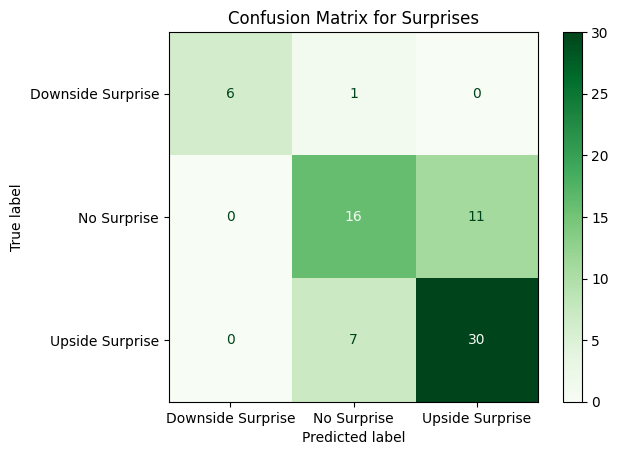

In [6]:
xgb_report = classification_report(y_test, xgb_multi.predict(X_test), target_names=['Downside Surprise', 'No Surprise', 'Upside Surprise'])
y_probs = xgb_multi.predict_proba(X_test)

print(f"ROC AUC Score for Multinomial Surprise Model: {roc_auc_score(y_test, y_probs, multi_class='ovr'):.4f}")
print("Classification Report for Upside Surprises:\n", xgb_report)

ConfusionMatrixDisplay.from_estimator(xgb_multi, X_test, y_test, display_labels=['Downside Surprise', 'No Surprise', 'Upside Surprise'], cmap='Greens')
plt.title('Confusion Matrix for Surprises')
plt.show()

### Optimized Multinomial Classification 

In [7]:
param_grid = {
    'max_depth': [1, 2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [50, 100, 200, 300],
    'subsample': [0.5, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.8, 1.0],
    'min_child_weight': [1, 2, 3, 5, 10],
    'gamma': [0, 0.1, 0.3, 0.5, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0, 10.0],
    'reg_lambda': [0.1, 1, 10, 100]
}

params = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(objective='multiclass', eval_metric='auc', seed=42),
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42
)

params.fit(X_train, y_train)
print(params.best_params_)
print(params.best_score_)

{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 50, 'min_child_weight': 2, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.5}
nan


In [8]:
opt_xgb = xgb.XGBClassifier(
    objective='multiclass',
    eval_metric='auc',
    **params.best_params_,
    seed=42
)
opt_xgb.fit(X_train, y_train, 
                   verbose=False, 
                   eval_set=[(X_test, y_test)]
                   )

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


### Cross-Validated Multinomial XGBoost Model Performance

After tuning the model's hyperparameters using cross-validation, the multinomial XGBoost classifier achieved an ROC-AUC score of 0.747, representing a meaningful improvement over the baseline model's ROC-AUC of 0.698. Overall classification accuracy also improved from 57% to 62%, indicating that the optimized model was better able to distinguish among downside surprise, no surprise, and upside surprise regimes.

The largest improvement occurred in the No Surprise class. The optimized model correctly classified 33 of 35 neutral observations, increasing recall from 0.69 to 0.94. This suggests that hyperparameter optimization substantially improved the model's ability to identify periods of normal labor market conditions and reduced the tendency to incorrectly classify neutral observations as surprise events.

Performance for the surprise classes was more mixed. Precision for downside surprises improved from 0.75 to 1.00, meaning every downside surprise prediction generated by the model was correct. However, downside surprise recall declined from 0.47 to 0.37, with the model correctly identifying 7 of 19 downside surprise observations compared to 9 of 19 in the baseline model. Similarly, upside surprise precision increased from 0.47 to 0.62, but recall declined from 0.44 to 0.28, with the model correctly identifying only 5 of 18 upside surprise observations.

The confusion matrix highlights a notable shift in the model's behavior. Compared to the baseline, the optimized model became substantially more conservative when predicting surprise regimes. Rather than incorrectly assigning observations to the wrong surprise category, the model increasingly classified both upside and downside surprises as No Surprise. For example, 11 of 19 downside surprises and 13 of 18 upside surprises were classified as neutral observations. This behavior reduced false positives and improved precision, but came at the cost of missing a larger proportion of actual surprise events.

Overall, the optimized multinomial model demonstrates stronger overall discrimination and higher classification accuracy than the baseline specification. However, these gains were driven primarily by improved identification of neutral labor market conditions rather than enhanced detection of surprise regimes. The results illustrate a common tradeoff in classification problems: hyperparameter optimization produced a more conservative model with higher precision and lower false-positive rates, but reduced its willingness to classify observations as upside or downside surprises.

Consequently, while the optimized model provides a more accurate overall classification framework, the baseline multinomial model was somewhat more effective at identifying surprise events themselves.

ROC AUC Score for Optimized Multinomial Surprise Model: 0.9025
Classification Report for Upside Surprises:
                    precision    recall  f1-score   support

Downside Surprise       1.00      0.86      0.92         7
      No Surprise       0.73      0.59      0.65        27
  Upside Surprise       0.72      0.84      0.78        37

         accuracy                           0.75        71
        macro avg       0.82      0.76      0.78        71
     weighted avg       0.75      0.75      0.74        71



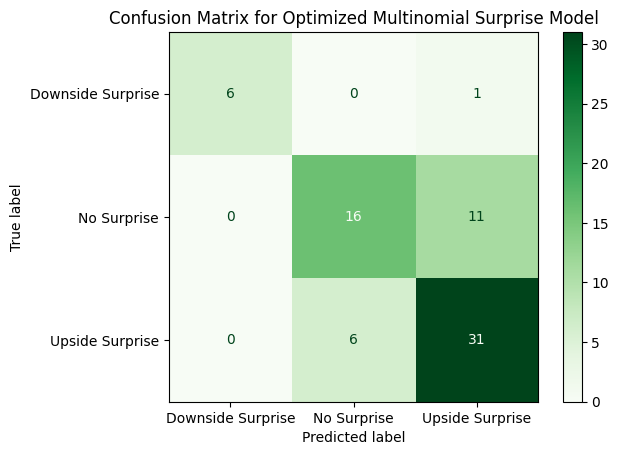

In [9]:
opt_xgb_report = classification_report(y_test, opt_xgb.predict(X_test), target_names=['Downside Surprise', 'No Surprise', 'Upside Surprise'])
y_probs_opt = opt_xgb.predict_proba(X_test)

print(f"ROC AUC Score for Optimized Multinomial Surprise Model: {roc_auc_score(y_test, y_probs_opt, multi_class='ovr'):.4f}")
print("Classification Report for Upside Surprises:\n", opt_xgb_report)

ConfusionMatrixDisplay.from_estimator(opt_xgb, X_test, y_test, display_labels=['Downside Surprise', 'No Surprise', 'Upside Surprise'], cmap='Greens')
plt.title('Confusion Matrix for Optimized Multinomial Surprise Model')
plt.show()

### Multinomial ROC Curve Analysis

Because ROC curves are inherently binary classification metrics, the multinomial model was evaluated using a one-vs-rest approach. Under this framework, a separate ROC curve is constructed for each class by treating the target class as the positive outcome and combining the remaining two classes into a single negative group. Consequently, each ROC-AUC score measures the model's ability to distinguish one labor market regime from all other regimes combined.

The model achieved class-specific ROC-AUC scores of 0.803 for downside surprises, 0.681 for no-surprise observations, and 0.757 for upside surprises.

The strongest performance was observed in the Downside Surprise class, with an ROC-AUC of 0.803. In practical terms, this means that when comparing a randomly selected downside surprise observation with a randomly selected observation from either the no-surprise or upside-surprise classes, the model assigns a higher downside-surprise probability approximately 80% of the time. This suggests that the model is identifying patterns that are often present before downside payroll surprises occur.

Similarly, the Upside Surprise ROC-AUC of 0.757 indicates that the model can distinguish upside surprise observations from all other labor market regimes roughly 76% of the time. Suggesting that the model is picking up signals associated with weaker labor market outcomes.

Performance was weakest for the No Surprise class, which achieved an ROC-AUC of 0.681. This implies that neutral labor market conditions are more difficult to separate from surprise regimes than downside and upside surprises are from the remainder of the sample. Given that no-surprise observations lie between upside and downside outcomes by construction, some overlap between classes is expected.

Importantly, the one-vs-rest ROC curves evaluate the model's ability to rank observations according to class-specific probabilities rather than its ability to assign the correct final class label. As a result, the ROC-AUC values are notably stronger than the corresponding classification metrics. While the confusion matrix shows that many surprise observations were ultimately classified as No Surprise, the ROC analysis indicates that the model frequently recognized the presence of surprise-related characteristics even when the final class prediction was incorrect.

Overall, the one-vs-rest ROC analysis suggests that the multinomial model contains meaningful predictive signal for both downside and upside payroll surprise regimes. The results indicate that the model is more effective at ranking observations by surprise risk than at making precise three-way classifications.

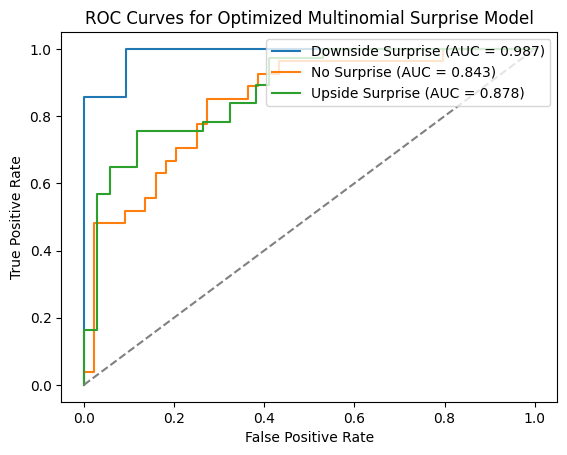

In [11]:
# One-vs-Rest ROC Curves for Multinomial Model

from sklearn.preprocessing import label_binarize

y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
y_probs_opt = opt_xgb.predict_proba(X_test)

for i, label in enumerate(['Downside Surprise', 'No Surprise', 'Upside Surprise']):
    fpr, tpr, thresholds = roc_curve(
        y_test_binarized[:, i], y_probs_opt[:, i]
        )
    plt.plot(
        fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y_test_binarized[:, i], 
        y_probs_opt[:, i]):.3f})")

plt.title("ROC Curves for Optimized Multinomial Surprise Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.legend(loc='upper right',
    labels=[
         f"Downside Surprise (AUC = {roc_auc_score(y_test_binarized[:, 0], y_probs_opt[:, 0]):.3f})",
        f"No Surprise (AUC = {roc_auc_score(y_test_binarized[:, 1], y_probs_opt[:, 1]):.3f})",
        f"Upside Surprise (AUC = {roc_auc_score(y_test_binarized[:, 2], y_probs_opt[:, 2]):.3f})"
        ]
)
plt.show()